# Nesta data preparation

## Purpose
Clean and prepare the Nesta creative-industries dataset for the Ball Mapper
analysis. Restrict the data to England and Wales, handle missing sector values,
and calculate creative-sector location quotients (LQs). Also produces the
descriptive checks and tables used to justify the LQ approach.

## Input
`nesta.csv` (Nesta TTWA-level creative-industries data, 229 TTWAs)

## Main steps
- Check missingness in the seven sector employment columns (2011–2014), overall and by region
- Compare completeness with the 2015-2016 data (196 vs 117 complete profiles, so 2011–2014 is used)
- Exclude Scotland and Northern Ireland, leaving 173 England & Wales TTWAs
- Fill the remaining missing sector employment values with 0
- Check that employment and business counts are highly correlated (raw and as LQs)
- Show why raw counts are unsuitable (London dominates in absolute size)
- Calculate employment LQs for the seven sub-sectors and overall creative LQ,
  using creative + non-creative employment as the total
- Produce the LQ correlation heatmap and descriptive statistics table (Table 3.1)
- Exploratory PCA on the sector LQs (not reported in the ERP)

## Output
`data/processed/nesta_ball.csv`: 173 England & Wales TTWAs with raw sector
employment, shares and LQs, used as input to the Ball Mapper notebook.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

In [107]:
nesta = pd.read_csv('/Users/scandimimi/Documents/Manchester/ERP/nesta.csv')

In [108]:
nesta = nesta.rename(columns={'Unnamed: 0': 'ttwa'}).reset_index(drop=True)

In [109]:
print(nesta.shape)
nesta.head()

(229, 76)


,ttwa,Region / Nation,Advertising and marketing: Employment 2011-2014,All creative industries: Employment 2011-2014,Architecture: Employment 2011-2014,"Design: product, graphic and fashion design: Employment 2011-2014","Film, TV, video, radio and photography: Employment 2011-2014","IT, software and computer services: Employment 2011-2014","Music, performing and visual arts: Employment 2011-2014",Publishing: Employment 2011-2014,...,All creative industries: Change in number of businesses (total),Architecture: Change in number of businesses (total),"Design: product, graphic and fashion design: Change in number of businesses (total)","Film, TV, video, radio and photography: Change in number of businesses (total)","IT, software and computer services: Change in number of businesses (total)","Music, performing and visual arts: Change in number of businesses (total)",Publishing: Change in number of businesses (total),not_creative: Change in number of businesses (total),Creative GVA 2015-2016 (Million £),Creative GVA 2015-2016 (% of total)
0,Aberdeen,Scotland,187.00,3652.25,596.25,210.75,242.50,1368.25,514.75,532.75,...,92.5,-8.5,7.0,-1.5,86.0,1.0,0.5,3890.000000,111.54,1.79
1,Aberystwyth,Wales,30.50,376.00,29.50,8.25,21.50,96.25,63.25,126.75,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.947368,3.80,0.76
2,Alness and Invergordon,Scotland,5.00,79.50,15.50,NaN,5.75,17.50,11.75,NaN,...,3.5,NaN,NaN,NaN,NaN,NaN,NaN,18.333333,1.29,0.59
3,Andover,South East,76.25,975.25,31.75,78.00,92.25,352.00,61.75,283.25,...,59.0,NaN,8.5,-4.5,43.0,9.0,3.0,532.902299,28.86,2.37
4,Arbroath and Montrose,Scotland,9.00,98.00,27.75,10.25,12.75,31.00,2.75,4.50,...,3.5,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,2.23,0.54


In [110]:
sector_cols = [
    "Advertising and marketing: Employment 2011-2014",
    "Architecture: Employment 2011-2014",
    "Design: product, graphic and fashion design: Employment 2011-2014",
    "Film, TV, video, radio and photography: Employment 2011-2014",
    "IT, software and computer services: Employment 2011-2014",
    "Music, performing and visual arts: Employment 2011-2014",
    "Publishing: Employment 2011-2014"
]


Checking for missingness

In [111]:
employment_missing = pd.DataFrame({
    "missing_n": nesta[sector_cols].isna().sum(),
    "missing_percent": nesta[sector_cols].isna().mean() * 100
})

employment_missing

,missing_n,missing_percent
Advertising and marketing: Employment 2011-2014,23,10.043668
Architecture: Employment 2011-2014,16,6.986900
"Design: product, graphic and fashion design: Employment 2011-2014",16,6.986900
"Film, TV, video, radio and photography: Employment 2011-2014",16,6.986900
"IT, software and computer services: Employment 2011-2014",2,0.873362
"Music, performing and visual arts: Employment 2011-2014",9,3.930131
Publishing: Employment 2011-2014,24,10.480349


In [112]:
missing_all_sectors = nesta[sector_cols].isna().sum(axis=1)

print("TTWAs missing at least one sector:", (missing_all_sectors > 0).sum())
print("TTWAs with complete sector data:", (missing_all_sectors == 0).sum())

TTWAs missing at least one sector: 33
TTWAs with complete sector data: 196


In [113]:
missing_all_sectors = nesta[sector_cols].isna().sum(axis=1)

nesta["missing_any_sector"] = missing_all_sectors > 0

In [114]:
missing_by_region = nesta.groupby("Region / Nation")["missing_any_sector"].agg(
    ["sum", "count"]
)

missing_by_region["percent_missing"] = (
    missing_by_region["sum"] / missing_by_region["count"] * 100
)

missing_by_region

,sum,count,percent_missing
Region / Nation,,,
East Midlands,0,16,0.000000
East of England,0,19,0.000000
London,0,2,0.000000
North East,0,9,0.000000
North West,1,17,5.882353
Northern Ireland,1,10,10.000000
Scotland,27,46,58.695652
South East,0,24,0.000000
South West,0,34,0.000000


In [115]:
missing_detail = nesta.loc[
    nesta[sector_cols].isna().any(axis=1) & (nesta["Region / Nation"] != "Scotland"),
    ["ttwa", "Region / Nation"] + sector_cols
]

missing_detail

,ttwa,Region / Nation,Advertising and marketing: Employment 2011-2014,Architecture: Employment 2011-2014,"Design: product, graphic and fashion design: Employment 2011-2014","Film, TV, video, radio and photography: Employment 2011-2014","IT, software and computer services: Employment 2011-2014","Music, performing and visual arts: Employment 2011-2014",Publishing: Employment 2011-2014
29,Brecon,Wales,5.75,20.75,25.75,32.50,43.25,73.50,NaN
32,Bridlington,Yorkshire and The Humber,5.00,15.00,25.75,7.25,34.50,52.25,NaN
83,Enniskillen,Northern Ireland,NaN,38.75,15.00,19.25,34.00,7.50,NaN
210,Tywyn and Dolgellau,Wales,11.75,6.75,NaN,15.00,12.25,25.25,19.25
217,Whitby,Yorkshire and The Humber,3.75,7.25,NaN,7.25,38.75,12.25,4.00
218,Whitehaven,North West,NaN,15.75,11.25,7.75,41.75,29.75,9.25


In [116]:
nesta_ew = nesta[
    ~nesta["Region / Nation"].isin(["Scotland", "Northern Ireland"])
].copy()

print(nesta_ew.shape)

(173, 77)


Comparison with 2015-2016 data

In [117]:
creative_sectors = [
    "Advertising and marketing",
    "Architecture",
    "Design: product, graphic and fashion design",
    "Film, TV, video, radio and photography",
    "IT, software and computer services",
    "Music, performing and visual arts",
    "Publishing"
]

cols_2011_14 = [
    f"{sector}: Employment 2011-2014"
    for sector in creative_sectors
]

cols_2015_16 = [
    f"{sector}: Employment 2015-2016"
    for sector in creative_sectors
]

# A TTWA is "complete" only if all seven sector values are present
complete_2011_14 = nesta[cols_2011_14].notna().all(axis=1)
complete_2015_16 = nesta[cols_2015_16].notna().all(axis=1)

# Count complete TTWA sector profiles
n_complete_2011_14 = complete_2011_14.sum()
n_complete_2015_16 = complete_2015_16.sum()

print("Complete TTWA profiles, 2011-2014:", n_complete_2011_14)
print("Complete TTWA profiles, 2015-2016:", n_complete_2015_16)

Complete TTWA profiles, 2011-2014: 196
Complete TTWA profiles, 2015-2016: 117


In [118]:
complete_2011_14 = nesta_ew[cols_2011_14].notna().all(axis=1)
complete_2015_16 = nesta_ew[cols_2015_16].notna().all(axis=1)

print(f"England & Wales TTWAs: {len(nesta_ew)}")
print(f"Complete 2011-2014 profiles: {complete_2011_14.sum()}")
print(f"Complete 2015-2016 profiles: {complete_2015_16.sum()}")


England & Wales TTWAs: 173
Complete 2011-2014 profiles: 168
Complete 2015-2016 profiles: 110


In [119]:
nesta_ew["Region / Nation"].value_counts()

Region / Nation
South West                  34
South East                  24
Wales                       19
Yorkshire and The Humber    19
East of England             19
North West                  17
East Midlands               16
West Midlands               14
North East                   9
London                       2
Name: count, dtype: int64

In [120]:
excluded_ttwas = nesta_ew[
    nesta_ew[sector_cols].isna().any(axis=1)
][["ttwa", "Region / Nation"]]

excluded_ttwas

,ttwa,Region / Nation
29,Brecon,Wales
32,Bridlington,Yorkshire and The Humber
210,Tywyn and Dolgellau,Wales
217,Whitby,Yorkshire and The Humber
218,Whitehaven,North West


In [121]:
missing_places = nesta_ew[
    nesta_ew[sector_cols].isna().any(axis=1)
][
    [
        "ttwa",
        "All creative industries: Employment 2011-2014",
        "not_creative: Employment 2011-2014"
    ]
]

missing_places

,ttwa,All creative industries: Employment 2011-2014,not_creative: Employment 2011-2014
29,Brecon,230.50,10477.272730
32,Bridlington,156.75,8708.333333
210,Tywyn and Dolgellau,93.00,6200.000000
217,Whitby,73.50,6681.818182
218,Whitehaven,117.75,19625.000000


In [122]:
nesta_ball = nesta_ew.copy()

nesta_ball[sector_cols] = nesta_ball[sector_cols].fillna(0)

In [123]:
nesta_ball[sector_cols].isna().sum()

Advertising and marketing: Employment 2011-2014                      0
Architecture: Employment 2011-2014                                   0
Design: product, graphic and fashion design: Employment 2011-2014    0
Film, TV, video, radio and photography: Employment 2011-2014         0
IT, software and computer services: Employment 2011-2014             0
Music, performing and visual arts: Employment 2011-2014              0
Publishing: Employment 2011-2014                                     0
dtype: int64

Exploring business counts

In [124]:
[b for b in nesta_ew.columns if "Number of businesses 2011-2014" in b]

['Advertising and marketing: Number of businesses 2011-2014',
 'All creative industries: Number of businesses 2011-2014',
 'Architecture: Number of businesses 2011-2014',
 'Design: product, graphic and fashion design: Number of businesses 2011-2014',
 'Film, TV, video, radio and photography: Number of businesses 2011-2014',
 'IT, software and computer services: Number of businesses 2011-2014',
 'Music, performing and visual arts: Number of businesses 2011-2014',
 'Publishing: Number of businesses 2011-2014',
 'not_creative: Number of businesses 2011-2014']

In [125]:
business_cols = [
    "Advertising and marketing: Number of businesses 2011-2014",
    "Architecture: Number of businesses 2011-2014",
    "Design: product, graphic and fashion design: Number of businesses 2011-2014",
    "Film, TV, video, radio and photography: Number of businesses 2011-2014",
    "IT, software and computer services: Number of businesses 2011-2014",
    "Music, performing and visual arts: Number of businesses 2011-2014",
    "Publishing: Number of businesses 2011-2014"
]

In [126]:
business_missing = pd.DataFrame({
    "missing_n": nesta_ew[business_cols].isna().sum(),
    "missing_percent": nesta_ew[business_cols].isna().mean() * 100
})

business_missing

,missing_n,missing_percent
Advertising and marketing: Number of businesses 2011-2014,1,0.578035
Architecture: Number of businesses 2011-2014,0,0.000000
"Design: product, graphic and fashion design: Number of businesses 2011-2014",2,1.156069
"Film, TV, video, radio and photography: Number of businesses 2011-2014",0,0.000000
"IT, software and computer services: Number of businesses 2011-2014",0,0.000000
"Music, performing and visual arts: Number of businesses 2011-2014",0,0.000000
Publishing: Number of businesses 2011-2014,2,1.156069


Exploring correlations between employment and business counts (overall & by sector)

In [127]:
comparison = pd.DataFrame({
    "employment_creative_total": nesta_ew[sector_cols].sum(axis=1),
    "business_creative_total": nesta_ew[business_cols].sum(axis=1)
})

comparison.corr()

,employment_creative_total,business_creative_total
employment_creative_total,1.000000,0.997578
business_creative_total,0.997578,1.000000


In [128]:
sector_comparison = pd.DataFrame()

for e, b in zip(sector_cols, business_cols):
    sector_comparison[e] = nesta_ew[e]
    sector_comparison[b] = nesta_ew[b]

sector_comparison.corr()

,Advertising and marketing: Employment 2011-2014,Advertising and marketing: Number of businesses 2011-2014,Architecture: Employment 2011-2014,Architecture: Number of businesses 2011-2014,"Design: product, graphic and fashion design: Employment 2011-2014","Design: product, graphic and fashion design: Number of businesses 2011-2014","Film, TV, video, radio and photography: Employment 2011-2014","Film, TV, video, radio and photography: Number of businesses 2011-2014","IT, software and computer services: Employment 2011-2014","IT, software and computer services: Number of businesses 2011-2014","Music, performing and visual arts: Employment 2011-2014","Music, performing and visual arts: Number of businesses 2011-2014",Publishing: Employment 2011-2014,Publishing: Number of businesses 2011-2014
Advertising and marketing: Employment 2011-2014,1.000000,0.994628,0.995049,0.991276,0.994762,0.993160,0.990612,0.993540,0.937520,0.974120,0.993400,0.994508,0.954473,0.992819
Advertising and marketing: Number of businesses 2011-2014,0.994628,1.000000,0.995879,0.997830,0.997511,0.998128,0.991459,0.994808,0.951843,0.987474,0.991577,0.994369,0.949004,0.995825
Architecture: Employment 2011-2014,0.995049,0.995879,1.000000,0.996075,0.998273,0.996811,0.989585,0.994014,0.932612,0.974689,0.994408,0.995049,0.956494,0.993834
Architecture: Number of businesses 2011-2014,0.991276,0.997830,0.996075,1.000000,0.997026,0.997836,0.986585,0.991275,0.948941,0.985960,0.989250,0.991514,0.950652,0.995392
"Design: product, graphic and fashion design: Employment 2011-2014",0.994762,0.997511,0.998273,0.997026,1.000000,0.999043,0.989433,0.994701,0.942998,0.981375,0.993826,0.995513,0.954733,0.995773
"Design: product, graphic and fashion design: Number of businesses 2011-2014",0.993160,0.998128,0.996811,0.997836,0.999043,1.000000,0.988526,0.995335,0.948461,0.985225,0.993847,0.996026,0.954458,0.997312
"Film, TV, video, radio and photography: Employment 2011-2014",0.990612,0.991459,0.989585,0.986585,0.989433,0.988526,1.000000,0.995179,0.932687,0.974253,0.987145,0.992540,0.945915,0.985734
"Film, TV, video, radio and photography: Number of businesses 2011-2014",0.993540,0.994808,0.994014,0.991275,0.994701,0.995335,0.995179,1.000000,0.939273,0.978577,0.995069,0.999065,0.953481,0.993978
"IT, software and computer services: Employment 2011-2014",0.937520,0.951843,0.932612,0.948941,0.942998,0.948461,0.932687,0.939273,1.000000,0.982339,0.933240,0.934161,0.874957,0.944483
"IT, software and computer services: Number of businesses 2011-2014",0.974120,0.987474,0.974689,0.985960,0.981375,0.985225,0.974253,0.978577,0.982339,1.000000,0.968793,0.974897,0.922854,0.981649


In [129]:
corr = sector_comparison.corr()
corr.min().min(), corr.max().max()

(0.8749567670535602, 1.0)

Cutting down columns to get columns for Ball Mapper

In [130]:
keep_cols = [
    "ttwa",
    "Region / Nation",
    "All creative industries: Employment 2011-2014",
    "not_creative: Employment 2011-2014",
    "Advertising and marketing: Employment 2011-2014",
    "Architecture: Employment 2011-2014",
    "Design: product, graphic and fashion design: Employment 2011-2014",
    "Film, TV, video, radio and photography: Employment 2011-2014",
    "IT, software and computer services: Employment 2011-2014",
    "Music, performing and visual arts: Employment 2011-2014",
    "Publishing: Employment 2011-2014"
]

nesta_ball = nesta_ball[keep_cols].dropna().copy()

print(nesta_ball.shape)

(173, 11)


Why Location Quotients are necessary

In [131]:
id="raw_eda1"
nesta_ball["All creative industries: Employment 2011-2014"].describe()

count       173.000000
mean       6052.826590
std       31722.695995
min          73.500000
25%         434.250000
50%        1141.500000
75%        3873.750000
max      409073.000000
Name: All creative industries: Employment 2011-2014, dtype: float64

In [132]:
id="raw_eda2"
nesta_ball[
    ["ttwa", "All creative industries: Employment 2011-2014"]
].sort_values(
    by="All creative industries: Employment 2011-2014",
    ascending=False
).head(10)

,ttwa,All creative industries: Employment 2011-2014
133,London,409073.00
188,Slough and Heathrow,65398.75
138,Manchester,41040.25
100,Guildford and Aldershot,38266.00
176,Reading,31141.00
167,Peterborough,18654.00
162,Oxford,17941.25
136,Luton,17511.50
42,Cambridge,16037.75
21,Birmingham,15881.00


In [133]:
id="raw_eda3"
london_creative = nesta_ball.loc[
    nesta_ball["ttwa"] == "London",
    "All creative industries: Employment 2011-2014"
].iloc[0]

median_creative = nesta_ball[
    "All creative industries: Employment 2011-2014"
].median()

london_creative / median_creative

np.float64(358.36443276390713)

Location Quotient Calculations

In [134]:
nesta_ball["total_employment"] = (
    nesta_ball["All creative industries: Employment 2011-2014"] +
    nesta_ball["not_creative: Employment 2011-2014"]
)

In [135]:
nesta_ball[[
    "ttwa",
    "All creative industries: Employment 2011-2014",
    "not_creative: Employment 2011-2014",
    "total_employment"
]].head()

,ttwa,All creative industries: Employment 2011-2014,not_creative: Employment 2011-2014,total_employment
1,Aberystwyth,376.00,19789.47368,20165.47368
3,Andover,975.25,27864.28571,28839.53571
5,Ashford,1467.75,41935.71429,43403.46429
9,Banbury,1745.50,37945.65217,39691.15217
10,Bangor and Holyhead,866.50,37673.91304,38540.41304


In [136]:
nesta_ball["total_employment"].describe()

count    1.730000e+02
mean     1.634458e+05
std      5.076590e+05
min      6.293000e+03
25%      2.767500e+04
50%      7.225196e+04
75%      1.596412e+05
max      6.424852e+06
Name: total_employment, dtype: float64

In [137]:
sector_cols = [
    "Advertising and marketing: Employment 2011-2014",
    "Architecture: Employment 2011-2014",
    "Design: product, graphic and fashion design: Employment 2011-2014",
    "Film, TV, video, radio and photography: Employment 2011-2014",
    "IT, software and computer services: Employment 2011-2014",
    "Music, performing and visual arts: Employment 2011-2014",
    "Publishing: Employment 2011-2014"
]

In [138]:
for sector in sector_cols:
    nesta_ball[f"{sector}_share"] = (
        nesta_ball[sector] / nesta_ball["total_employment"]
    )

In [139]:
national_shares = {}

for sector in sector_cols:
    national_shares[sector] = (
        nesta_ball[sector].sum() /
        nesta_ball["total_employment"].sum()
    )

national_shares

{'Advertising and marketing: Employment 2011-2014': np.float64(0.004627173506847054),
 'Architecture: Employment 2011-2014': np.float64(0.002007453844007378),
 'Design: product, graphic and fashion design: Employment 2011-2014': np.float64(0.001714972030970681),
 'Film, TV, video, radio and photography: Employment 2011-2014': np.float64(0.005554130694483655),
 'IT, software and computer services: Employment 2011-2014': np.float64(0.014710130576975147),
 'Music, performing and visual arts: Employment 2011-2014': np.float64(0.003571485773041525),
 'Publishing: Employment 2011-2014': np.float64(0.004845540653031397)}

In [140]:
for sector in sector_cols:
    nesta_ball[f"{sector}_LQ"] = (
        nesta_ball[f"{sector}_share"] /
        national_shares[sector]
    )

In [141]:
nesta_ball.filter(like="_LQ").describe()

,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,0.515673,0.837548,0.886465,0.413657,0.638398,0.757224,0.661071
std,0.475943,0.449146,0.458661,0.819811,0.592706,0.501381,1.360115
min,0.000000,0.212570,0.000000,0.035936,0.098705,0.116188,0.000000
25%,0.254680,0.513000,0.578570,0.154403,0.276173,0.422460,0.174240
50%,0.387566,0.759081,0.810557,0.257156,0.479932,0.608715,0.289422
75%,0.569841,1.057861,1.107796,0.411414,0.755072,0.914428,0.631293
max,3.077492,2.787328,2.706416,9.931177,4.476342,3.113405,15.195696


In [142]:
lq_cols = [col for col in nesta_ball.columns if "_LQ" in col]

for col in lq_cols:
    print("\n", col)
    print(
        nesta_ball[["ttwa", col]]
        .sort_values(by=col, ascending=False)
        .head(5)
    )


 Advertising and marketing: Employment 2011-2014_LQ
           ttwa  Advertising and marketing: Employment 2011-2014_LQ
12   Barnstaple                                           3.077492 
162      Oxford                                           2.807971 
176     Reading                                           2.309625 
133      London                                           2.124809 
55   Colchester                                           1.713439 

 Architecture: Employment 2011-2014_LQ
                          ttwa  Architecture: Employment 2011-2014_LQ
187                    Skipton                               2.787328
44                  Canterbury                               2.302883
120  Kingsbridge and Dartmouth                               2.292223
163         Pembroke and Tenby                               2.243297
102                  Harrogate                               1.873222

 Design: product, graphic and fashion design: Employment 2011-2014_LQ
        

In [143]:
id="raw_eda1"
nesta_ball["All creative industries: Employment 2011-2014"].describe()

count       173.000000
mean       6052.826590
std       31722.695995
min          73.500000
25%         434.250000
50%        1141.500000
75%        3873.750000
max      409073.000000
Name: All creative industries: Employment 2011-2014, dtype: float64

Correlations between the LQ columns (creative sub-sectors)

In [144]:
lq_cols = [col for col in nesta_ball.columns if "_LQ" in col]

nesta_ball[lq_cols].corr()

,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ
Advertising and marketing: Employment 2011-2014_LQ,1.000000,0.223777,0.279208,0.105396,0.470211,0.289521,0.194744
Architecture: Employment 2011-2014_LQ,0.223777,1.000000,0.464605,0.154046,0.112089,0.361954,0.107465
"Design: product, graphic and fashion design: Employment 2011-2014_LQ",0.279208,0.464605,1.000000,0.152454,0.269745,0.500320,0.070869
"Film, TV, video, radio and photography: Employment 2011-2014_LQ",0.105396,0.154046,0.152454,1.000000,0.050080,0.368137,0.103694
"IT, software and computer services: Employment 2011-2014_LQ",0.470211,0.112089,0.269745,0.050080,1.000000,0.249829,0.097256
"Music, performing and visual arts: Employment 2011-2014_LQ",0.289521,0.361954,0.500320,0.368137,0.249829,1.000000,0.017120
Publishing: Employment 2011-2014_LQ,0.194744,0.107465,0.070869,0.103694,0.097256,0.017120,1.000000


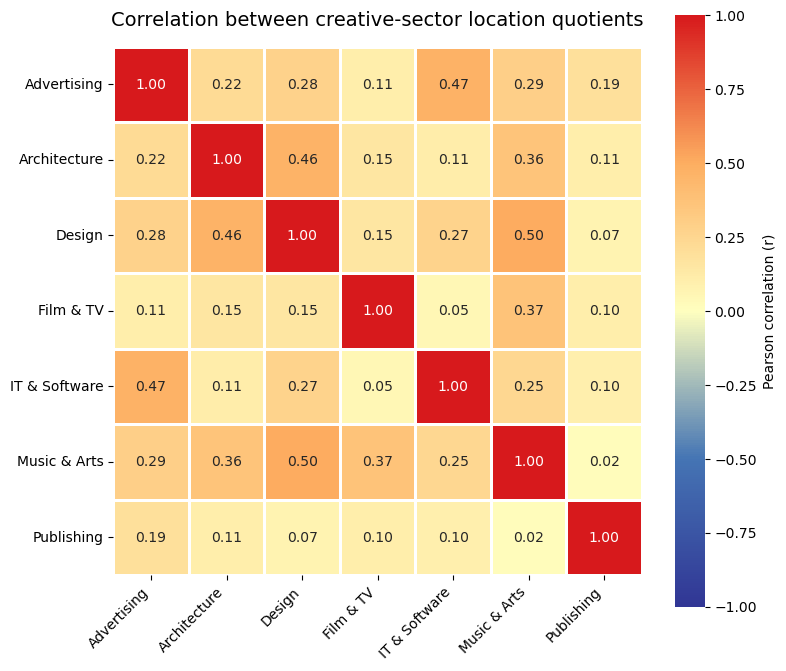

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

lq_cols = [col for col in nesta_ball.columns if "_LQ" in col]

lq_corr = nesta_ball[lq_cols].corr()

short_labels = {
    "Advertising and marketing: Employment 2011-2014_LQ": "Advertising",
    "Architecture: Employment 2011-2014_LQ": "Architecture",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ": "Design",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ": "Film & TV",
    "IT, software and computer services: Employment 2011-2014_LQ": "IT & Software",
    "Music, performing and visual arts: Employment 2011-2014_LQ": "Music & Arts",
    "Publishing: Employment 2011-2014_LQ": "Publishing",
    "creative_LQ": "Overall creative"
}

lq_corr = lq_corr.rename(
    index=short_labels,
    columns=short_labels
)

hyperlink_cmap = LinearSegmentedColormap.from_list(
    "hyperlink",
    [
        "#313695",  # deep indigo
        "#4575B4",  # blue
        "#FFFFBF",  # pale cream
        "#FDAE61",  # orange
        "#D7191C"   # red
    ]
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    lq_corr,
    cmap=hyperlink_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Pearson correlation (r)"}
)

plt.title(
    "Correlation between creative-sector location quotients",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Redoing sub-sector empployment count/business count correlations with LQs

In [146]:
business_cols = [
    c for c in nesta_ew.columns
    if "Number of businesses 2011-2014" in c
]

business_cols

['Advertising and marketing: Number of businesses 2011-2014',
 'All creative industries: Number of businesses 2011-2014',
 'Architecture: Number of businesses 2011-2014',
 'Design: product, graphic and fashion design: Number of businesses 2011-2014',
 'Film, TV, video, radio and photography: Number of businesses 2011-2014',
 'IT, software and computer services: Number of businesses 2011-2014',
 'Music, performing and visual arts: Number of businesses 2011-2014',
 'Publishing: Number of businesses 2011-2014',
 'not_creative: Number of businesses 2011-2014']

In [147]:
sectors = [
    "Advertising and marketing",
    "Architecture",
    "Design: product, graphic and fashion design",
    "Film, TV, video, radio and photography",
    "IT, software and computer services",
    "Music, performing and visual arts",
    "Publishing"
]

In [148]:
creative_business_col = "All creative industries: Number of businesses 2011-2014"
noncreative_business_col = "not_creative: Number of businesses 2011-2014"

nesta_ew["Total businesses 2011-2014"] = (
    nesta_ew[creative_business_col] +
    nesta_ew[noncreative_business_col]
)

In [149]:
total_business_col = "Total businesses 2011-2014"

for sector in sectors:

    sector_business_col = f"{sector}: Number of businesses 2011-2014"

    
    local_share = (
        nesta_ew[sector_business_col] /
        nesta_ew[total_business_col]
    )

    
    national_share = (
        nesta_ew[sector_business_col].sum() /
        nesta_ew[total_business_col].sum()
    )

    
    nesta_ew[f"{sector}: Businesses 2011-2014_LQ"] = (
        local_share / national_share
    )

In [150]:
business_lq_cols = [
    f"{sector}: Businesses 2011-2014_LQ"
    for sector in sectors
]

nesta_ew[business_lq_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Advertising and marketing: Businesses 2011-2014_LQ,172.0,0.677333,0.301722,0.137257,0.480370,0.637119,0.832501,1.785430
Architecture: Businesses 2011-2014_LQ,173.0,0.882079,0.265176,0.386997,0.712088,0.862167,1.039194,1.931256
"Design: product, graphic and fashion design: Businesses 2011-2014_LQ",171.0,0.760865,0.273474,0.257913,0.579169,0.730482,0.927667,1.808742
"Film, TV, video, radio and photography: Businesses 2011-2014_LQ",173.0,0.535082,0.305644,0.106207,0.327179,0.469475,0.658750,2.199269
"IT, software and computer services: Businesses 2011-2014_LQ",173.0,0.678484,0.384108,0.151418,0.374095,0.589909,0.865173,2.267944
"Music, performing and visual arts: Businesses 2011-2014_LQ",173.0,0.659610,0.315155,0.241818,0.441563,0.590768,0.780234,2.496753
Publishing: Businesses 2011-2014_LQ,171.0,0.853728,0.371216,0.230500,0.589916,0.778145,1.047850,2.557785


In [151]:
nesta_ew[
    ["ttwa"] + business_lq_cols
].head()

,ttwa,Advertising and marketing: Businesses 2011-2014_LQ,Architecture: Businesses 2011-2014_LQ,"Design: product, graphic and fashion design: Businesses 2011-2014_LQ","Film, TV, video, radio and photography: Businesses 2011-2014_LQ","IT, software and computer services: Businesses 2011-2014_LQ","Music, performing and visual arts: Businesses 2011-2014_LQ",Publishing: Businesses 2011-2014_LQ
1,Aberystwyth,0.344132,0.724704,0.257913,0.455053,0.281791,0.542038,1.712324
3,Andover,0.856924,0.661870,0.963345,0.632988,1.131171,0.718083,0.793960
5,Ashford,1.040254,1.062138,0.866254,0.550219,0.836034,0.780234,1.078348
9,Banbury,1.137436,1.057671,1.014836,0.773513,0.894425,0.901874,0.727666
10,Bangor and Holyhead,0.179723,0.707801,0.432949,0.977766,0.357402,0.901233,0.747347


In [152]:
[c for c in nesta_ew.columns if "LQ" in c]

['Advertising and marketing: Businesses 2011-2014_LQ',
 'Architecture: Businesses 2011-2014_LQ',
 'Design: product, graphic and fashion design: Businesses 2011-2014_LQ',
 'Film, TV, video, radio and photography: Businesses 2011-2014_LQ',
 'IT, software and computer services: Businesses 2011-2014_LQ',
 'Music, performing and visual arts: Businesses 2011-2014_LQ',
 'Publishing: Businesses 2011-2014_LQ']

In [153]:
for c in nesta_ew.columns:
    if (
        "Employment 2011-2014" in c
        or "Number of businesses 2011-2014" in c
    ):
        print(c)

Advertising and marketing: Employment 2011-2014
All creative industries: Employment 2011-2014
Architecture: Employment 2011-2014
Design: product, graphic and fashion design: Employment 2011-2014
Film, TV, video, radio and photography: Employment 2011-2014
IT, software and computer services: Employment 2011-2014
Music, performing and visual arts: Employment 2011-2014
Publishing: Employment 2011-2014
not_creative: Employment 2011-2014
Advertising and marketing: Number of businesses 2011-2014
All creative industries: Number of businesses 2011-2014
Architecture: Number of businesses 2011-2014
Design: product, graphic and fashion design: Number of businesses 2011-2014
Film, TV, video, radio and photography: Number of businesses 2011-2014
IT, software and computer services: Number of businesses 2011-2014
Music, performing and visual arts: Number of businesses 2011-2014
Publishing: Number of businesses 2011-2014
not_creative: Number of businesses 2011-2014


In [154]:
for c in nesta_ew.columns:
    if (
        "Employment 2011-2014" in c
        or "Number of businesses 2011-2014" in c
    ):
        print(c)

Advertising and marketing: Employment 2011-2014
All creative industries: Employment 2011-2014
Architecture: Employment 2011-2014
Design: product, graphic and fashion design: Employment 2011-2014
Film, TV, video, radio and photography: Employment 2011-2014
IT, software and computer services: Employment 2011-2014
Music, performing and visual arts: Employment 2011-2014
Publishing: Employment 2011-2014
not_creative: Employment 2011-2014
Advertising and marketing: Number of businesses 2011-2014
All creative industries: Number of businesses 2011-2014
Architecture: Number of businesses 2011-2014
Design: product, graphic and fashion design: Number of businesses 2011-2014
Film, TV, video, radio and photography: Number of businesses 2011-2014
IT, software and computer services: Number of businesses 2011-2014
Music, performing and visual arts: Number of businesses 2011-2014
Publishing: Number of businesses 2011-2014
not_creative: Number of businesses 2011-2014


In [155]:
for c in nesta_ew.columns:
    if (
        "Employment 2011-2014" in c
        or "Number of businesses 2011-2014" in c
    ):
        print(c)

Advertising and marketing: Employment 2011-2014
All creative industries: Employment 2011-2014
Architecture: Employment 2011-2014
Design: product, graphic and fashion design: Employment 2011-2014
Film, TV, video, radio and photography: Employment 2011-2014
IT, software and computer services: Employment 2011-2014
Music, performing and visual arts: Employment 2011-2014
Publishing: Employment 2011-2014
not_creative: Employment 2011-2014
Advertising and marketing: Number of businesses 2011-2014
All creative industries: Number of businesses 2011-2014
Architecture: Number of businesses 2011-2014
Design: product, graphic and fashion design: Number of businesses 2011-2014
Film, TV, video, radio and photography: Number of businesses 2011-2014
IT, software and computer services: Number of businesses 2011-2014
Music, performing and visual arts: Number of businesses 2011-2014
Publishing: Number of businesses 2011-2014
not_creative: Number of businesses 2011-2014


In [156]:
sectors = [
    "Advertising and marketing",
    "Architecture",
    "Design: product, graphic and fashion design",
    "Film, TV, video, radio and photography",
    "IT, software and computer services",
    "Music, performing and visual arts",
    "Publishing"
]

In [157]:
nesta_ew["total_employment"] = (
    nesta_ew["All creative industries: Employment 2011-2014"]
    + nesta_ew["not_creative: Employment 2011-2014"]
)

nesta_ew["total_businesses"] = (
    nesta_ew["All creative industries: Number of businesses 2011-2014"]
    + nesta_ew["not_creative: Number of businesses 2011-2014"]
)

In [158]:
def calculate_lq(df, sector_col, total_col):
    
    # TTWA's sector share
    local_share = df[sector_col] / df[total_col]
    
    # England + Wales sector share
    national_share = (
        df[sector_col].sum()
        / df[total_col].sum()
    )
    
    return local_share / national_share

In [159]:
for sector in sectors:
    
    emp_col = f"{sector}: Employment 2011-2014"
    bus_col = f"{sector}: Number of businesses 2011-2014"
    
    nesta_ew[f"{sector}_employment_LQ"] = calculate_lq(
        nesta_ew,
        emp_col,
        "total_employment"
    )
    
    nesta_ew[f"{sector}_business_LQ"] = calculate_lq(
        nesta_ew,
        bus_col,
        "total_businesses"
    )

In [160]:
lq_cols = [
    c for c in nesta_ew.columns
    if c.endswith("_LQ")
]

nesta_ew[lq_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Advertising and marketing: Businesses 2011-2014_LQ,172.0,0.677333,0.301722,0.137257,0.480370,0.637119,0.832501,1.785430
Architecture: Businesses 2011-2014_LQ,173.0,0.882079,0.265176,0.386997,0.712088,0.862167,1.039194,1.931256
"Design: product, graphic and fashion design: Businesses 2011-2014_LQ",171.0,0.760865,0.273474,0.257913,0.579169,0.730482,0.927667,1.808742
"Film, TV, video, radio and photography: Businesses 2011-2014_LQ",173.0,0.535082,0.305644,0.106207,0.327179,0.469475,0.658750,2.199269
"IT, software and computer services: Businesses 2011-2014_LQ",173.0,0.678484,0.384108,0.151418,0.374095,0.589909,0.865173,2.267944
"Music, performing and visual arts: Businesses 2011-2014_LQ",173.0,0.659610,0.315155,0.241818,0.441563,0.590768,0.780234,2.496753
Publishing: Businesses 2011-2014_LQ,171.0,0.853728,0.371216,0.230500,0.589916,0.778145,1.047850,2.557785
Advertising and marketing_employment_LQ,172.0,0.518671,0.475692,0.053653,0.256496,0.390020,0.570229,3.077492
Advertising and marketing_business_LQ,172.0,0.677333,0.301722,0.137257,0.480370,0.637119,0.832501,1.785430
Architecture_employment_LQ,173.0,0.837548,0.449146,0.212570,0.513000,0.759081,1.057861,2.787328


In [161]:
rows = []

for sector in sectors:
    
    emp_lq = f"{sector}_employment_LQ"
    bus_lq = f"{sector}_business_LQ"
    
    r = nesta_ew[[emp_lq, bus_lq]].corr().iloc[0, 1]
    
    rows.append({
        "Creative sub-sector": sector,
        "Employment–business LQ correlation": r
    })

table_B1 = pd.DataFrame(rows)

table_B1["Employment–business LQ correlation"] = (
    table_B1["Employment–business LQ correlation"].round(3)
)

table_B1

,Creative sub-sector,Employment–business LQ correlation
0,Advertising and marketing,0.654
1,Architecture,0.608
2,"Design: product, graphic and fashion design",0.589
3,"Film, TV, video, radio and photography",0.336
4,"IT, software and computer services",0.824
5,"Music, performing and visual arts",0.685
6,Publishing,0.346


In [162]:
rows = []

for sector in sectors:
    
    emp_raw = f"{sector}: Employment 2011-2014"
    bus_raw = f"{sector}: Number of businesses 2011-2014"
    
    emp_lq = f"{sector}_employment_LQ"
    bus_lq = f"{sector}_business_LQ"
    
    raw_r = nesta_ew[[emp_raw, bus_raw]].corr().iloc[0, 1]
    lq_r = nesta_ew[[emp_lq, bus_lq]].corr().iloc[0, 1]
    
    rows.append({
        "Sector": sector,
        "Raw employment–business r": raw_r,
        "Employment–business LQ r": lq_r
    })

comparison = pd.DataFrame(rows)

comparison[
    ["Raw employment–business r",
     "Employment–business LQ r"]
] = comparison[
    ["Raw employment–business r",
     "Employment–business LQ r"]
].round(3)

comparison

,Sector,Raw employment–business r,Employment–business LQ r
0,Advertising and marketing,0.995,0.654
1,Architecture,0.996,0.608
2,"Design: product, graphic and fashion design",0.999,0.589
3,"Film, TV, video, radio and photography",0.995,0.336
4,"IT, software and computer services",0.982,0.824
5,"Music, performing and visual arts",0.997,0.685
6,Publishing,0.960,0.346


overall creative LQ :

In [163]:
nesta_ball["total_employment"] = (
    nesta_ball["All creative industries: Employment 2011-2014"] +
    nesta_ball["not_creative: Employment 2011-2014"]
)

In [164]:
nesta_ball["creative_share"] = (
    nesta_ball["All creative industries: Employment 2011-2014"]
    / nesta_ball["total_employment"]
)

national_creative_share = (
    nesta_ball["All creative industries: Employment 2011-2014"].sum()
    / nesta_ball["total_employment"].sum()
)

nesta_ball["creative_LQ"] = (
    nesta_ball["creative_share"]
    / national_creative_share
)

In [165]:
nesta_ball["creative_LQ"].describe()

count    173.000000
mean       0.626844
std        0.407725
min        0.161053
25%        0.372825
50%        0.529475
75%        0.735496
max        2.588011
Name: creative_LQ, dtype: float64

In [166]:
nesta_ball["creative_group"] = (
    nesta_ball["creative_LQ"] > 1
)

nesta_ball["creative_group"].value_counts()

creative_group
False    156
True      17
Name: count, dtype: int64

In [167]:
import pandas as pd

sector_lq_cols = [
    col for col in nesta_ball.columns
    if "_LQ" in col and col != "creative_LQ"
]

sector_names = {
    "Advertising and marketing: Employment 2011-2014_LQ": "Advertising & marketing",
    "Architecture: Employment 2011-2014_LQ": "Architecture",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ": "Design",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ": "Film, TV & photography",
    "IT, software and computer services: Employment 2011-2014_LQ": "IT & software",
    "Music, performing and visual arts: Employment 2011-2014_LQ": "Music & arts",
    "Publishing: Employment 2011-2014_LQ": "Publishing"
}

rows = []

for col in sector_lq_cols:
    
    values = nesta_ball[col].dropna()
    

    max_idx = nesta_ball[col].idxmax()
    
    rows.append({
        "Creative sub-sector": sector_names.get(col, col),
        "N": values.count(),
        "Mean": values.mean(),
        "Median": values.median(),
        "SD": values.std(),
        "Skewness": values.skew(),
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Maximum TTWA": nesta_ball.loc[max_idx, "ttwa"]
    })

table_3_1 = pd.DataFrame(rows)

numeric_cols = [
    "Mean", "Median", "SD",
    "Skewness", "Minimum", "Maximum"
]

table_3_1[numeric_cols] = table_3_1[numeric_cols].round(2)

table_3_1

,Creative sub-sector,N,Mean,Median,SD,Skewness,Minimum,Maximum,Maximum TTWA
0,Advertising & marketing,173,0.52,0.39,0.48,2.63,0.00,3.08,Barnstaple
1,Architecture,173,0.84,0.76,0.45,1.35,0.21,2.79,Skipton
2,Design,173,0.89,0.81,0.46,1.26,0.00,2.71,Bridport
3,"Film, TV & photography",173,0.41,0.26,0.82,9.50,0.04,9.93,Penzance
4,IT & software,173,0.64,0.48,0.59,3.40,0.10,4.48,Reading
5,Music & arts,173,0.76,0.61,0.50,1.75,0.12,3.11,Brighton
6,Publishing,173,0.66,0.29,1.36,7.78,0.00,15.20,Peterborough


PCA (Not addressed in ERP)

In [168]:
lq_cols = [
    col for col in nesta_ball.columns 
    if "_LQ" in col and col != "creative_LQ"
]

lq_matrix = nesta_ball[lq_cols].copy()

lq_matrix.head()

,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ
1,0.326870,0.728732,0.238555,0.191961,0.324471,0.878220,1.297171
3,0.571394,0.548416,1.577064,0.575920,0.829732,0.599515,2.026933
5,0.516592,0.777570,1.128490,0.309041,1.412359,0.914428,0.448141
9,1.084898,1.728830,1.975930,0.900432,1.516197,0.980555,0.266476
10,0.067290,0.720581,0.457670,1.256666,0.538422,1.097013,0.231594


In [169]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

lq_scaled = scaler.fit_transform(lq_matrix)

In [170]:
from sklearn.decomposition import PCA

pca = PCA()

pca_result = pca.fit_transform(lq_scaled)

In [171]:
explained_variance = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Variance explained": pca.explained_variance_ratio_,
    "Cumulative variance": pca.explained_variance_ratio_.cumsum()
})

explained_variance

,PC,Variance explained,Cumulative variance
0,1,0.349375,0.349375
1,2,0.166826,0.516200
2,3,0.142661,0.658861
3,4,0.128093,0.786954
4,5,0.081280,0.868234
5,6,0.071309,0.939544
6,7,0.060456,1.000000


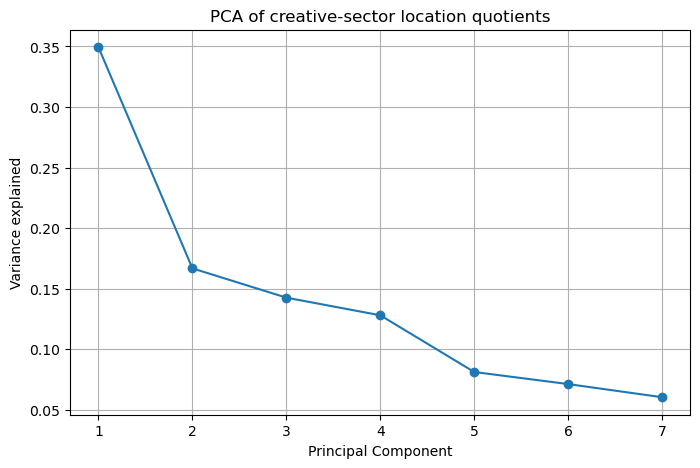

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    explained_variance["PC"],
    explained_variance["Variance explained"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Variance explained")
plt.title("PCA of creative-sector location quotients")

plt.xticks(explained_variance["PC"])
plt.grid(True)

plt.show()

In [173]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i}" for i in range(1, len(lq_cols)+1)],
    index=lq_cols
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Advertising and marketing: Employment 2011-2014_LQ,0.405128,0.487681,-0.043036,0.130928,0.505991,-0.529228,0.207209
Architecture: Employment 2011-2014_LQ,0.402264,-0.271448,-0.049907,-0.547134,0.537146,0.352823,-0.222810
"Design: product, graphic and fashion design: Employment 2011-2014_LQ",0.474564,-0.180631,-0.221752,-0.281869,-0.460789,-0.048143,0.631580
"Film, TV, video, radio and photography: Employment 2011-2014_LQ",0.267442,-0.388876,0.514439,0.576069,0.195168,0.245907,0.286682
"IT, software and computer services: Employment 2011-2014_LQ",0.353768,0.536033,-0.245272,0.294575,-0.187216,0.617235,-0.156703
"Music, performing and visual arts: Employment 2011-2014_LQ",0.477193,-0.301518,-0.064854,0.211974,-0.303146,-0.388899,-0.623775
Publishing: Employment 2011-2014_LQ,0.156379,0.355510,0.785794,-0.374819,-0.279435,-0.020589,-0.112648


In [175]:
nesta_ball.to_csv("/Users/scandimimi/Documents/Manchester/ERP Code/Ball Mapper Data/nesta_ball.csv", index=False)